# Clinical Trial Landscape -- Antibody Therapeutics in Oncology
**Prepared for:** Executive / Portfolio Strategy Review
**Analyst view:** Head of Data Analytics (clinical-stage competitive intelligence)
**Source data:** `input/clinical_final_version1.csv` (/Users/revathisekar/Documents/vibe analytics trial 2/input/clinical_final_version1.csv)
**Scope:** Antibody-modality oncology clinical trials (mAb, ADC, bispecific, BiTE, CAR-T, radioligand, PROTAC),
filtered to `in_scope == True`.
**Target taxonomy:** the curated **`target_harmonized`** column only (no raw `targets_hgnc`/`target_name`).

This notebook builds the full analytic base end-to-end (DuckDB SQL + pandas), then walks through 26
entries: landscape overview -> phase funnels -> target validation scorecards -> tumor-type cuts ->
regimen/modality "subtle difference" divergence analysis -> clinical whitespace scoring -> a portfolio
shortlist -> executive summary. Every table and chart below is generated live from the CSV; nothing is
hand-typed.

## Entry 1: Setup, Scope & Data Load

In [1]:
# Executive framing -----------------------------------------------------
# We are evaluating antibody-based oncology assets (mAb / ADC / bispecific /
# BiTE / CAR-T / radioligand / PROTAC) currently or historically in the
# clinic, to decide WHERE our own antibody-therapeutics program should
# place its target + modality bet. Source: input/clinical_final_version1.csv
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW raw_trials AS SELECT * FROM read_csv_auto('{INPUT_CSV}', ALL_VARCHAR=FALSE, SAMPLE_SIZE=-1)")
raw = con.sql("SELECT * FROM raw_trials").df()
print(f"Raw rows: {len(raw):,}   Columns: {raw.shape[1]}   Unique NCTs: {raw['nct'].nunique():,}")
print()
print(con.sql('''
    SELECT in_scope, COUNT(*) AS n_rows
    FROM raw_trials GROUP BY 1 ORDER BY 2 DESC
''').df().to_string(index=False))

Raw rows: 19,357   Columns: 63   Unique NCTs: 18,383

 in_scope  n_rows
     True   16648
    False    2684
     <NA>      25


## Entry 2: Analytic Base Table -- Scope Filter, Canonical Phase & Outcome Bucket

In [2]:
# Keep in-scope antibody-modality oncology trials only. Build a canonical
# phase (favors CT.gov phase, falls back to curated `phase` text) and a
# 4-way outcome bucket (Success / Failure / Ongoing-Pending / Unclear) off
# the curated `outcome` column -- this is our label for "succeeded /
# failed / still-in-trial".
df = raw[raw["in_scope"] == True].copy()  # noqa: E712 (nullable BooleanArray from DuckDB)

def canon_phase(raw_phase, ctgov_phase):
    s = str(ctgov_phase) if pd.notna(ctgov_phase) and str(ctgov_phase) != "None" else str(raw_phase)
    s = s.upper()
    has1 = ("PHASE1" in s) or ("EARLY_PHASE1" in s)
    has2 = "PHASE2" in s
    has3 = "PHASE3" in s
    has4 = "PHASE4" in s
    if has4:
        return "Phase 4"
    if has3 and has2:
        return "Phase 2/3"
    if has3:
        return "Phase 3"
    if has2 and has1:
        return "Phase 1/2"
    if has2:
        return "Phase 2"
    if has1:
        return "Phase 1"
    return "Unknown"

df["phase_canon"] = [canon_phase(p, c) for p, c in zip(df["phase"], df["ctgov_phase"])]

OUTCOME_BUCKET = {
    "positive": "Success", "approved": "Success",
    "negative": "Failure", "terminated": "Failure",
    "ongoing": "Ongoing/Pending", "pending": "Ongoing/Pending",
    "unclear": "Unclear",
}
df["outcome_bucket"] = df["outcome"].map(OUTCOME_BUCKET).fillna("Unclear")

df["start_year"] = pd.to_datetime(df["start_date"], errors="coerce", format="mixed").dt.year
df["target_h"] = df["target_harmonized"].replace({"": np.nan})
df["n_targets_h"] = pd.to_numeric(df["n_targets_harmonized"], errors="coerce")

con.register("trials", df)
print(f"In-scope analytic base: {len(df):,} rows ({df['nct'].nunique():,} unique NCTs)")
print()
print("Phase canonicalization coverage:")
print(df["phase_canon"].value_counts(dropna=False).to_string())
print()
print("Outcome bucket coverage:")
print(df["outcome_bucket"].value_counts(dropna=False).to_string())

In-scope analytic base: 16,648 rows (15,851 unique NCTs)

Phase canonicalization coverage:
phase_canon
Phase 2      6799
Phase 1      4015
Phase 1/2    2375
Phase 3      1567
Unknown      1561
Phase 2/3     196
Phase 4       135

Outcome bucket coverage:
outcome_bucket
Ongoing/Pending    10192
Failure             2678
Unclear             2463
Success             1315


## Entry 3: Tumor-Type Harmonization Engine (Solid Tumor Classifier)

In [3]:
# There is no curated tumor-type column, so we build one from
# ctgov_conditions (fallback m_conditions) using an ordered keyword/regex
# classifier -- most-specific categories checked first (e.g. NSCLC before
# generic "lung"). A trial can carry MULTIPLE tags (basket trials); we
# keep the full tag list for tumor-specific cuts and a single
# `tumor_primary` (first match) for row-level summaries.
TUMOR_CATEGORIES = [
    ("NSCLC", r"non[- ]?small[- ]?cell lung|nsclc"),
    ("SCLC", r"small[- ]?cell lung (carcinoma|cancer)|\bsclc\b"),
    ("Lung_Other", r"\blung\b|pulmonary"),
    ("Breast", r"\bbreast\b"),
    ("Ovarian", r"ovarian|\bovary\b"),
    ("Endometrial_Uterine", r"endometrial|\buterine\b"),
    ("Cervical", r"cervical|\bcervix\b"),
    ("Colorectal", r"colorectal|\bcolon\b|\brectal\b|\brectum\b"),
    ("Gastric_Esophageal", r"gastric|\bstomach\b|esophageal|oesophageal|gastroesophageal|\bgej\b"),
    ("Hepatocellular", r"hepatocellular|\bhcc\b"),
    ("Biliary_Cholangio", r"cholangiocarcinoma|\bbiliary\b"),
    ("Pancreatic", r"pancreatic|\bpancreas\b"),
    ("RCC", r"renal cell|\brcc\b|kidney cancer"),
    ("Bladder_Urothelial", r"\bbladder\b|urothelial"),
    ("Prostate", r"prostat"),
    ("Melanoma", r"melanoma"),
    ("HNSCC", r"head and neck|nasopharyngeal|oropharyngeal|laryngeal|hypopharyngeal|oral cavity"),
    ("Glioma_CNS", r"glioma|glioblastoma|astrocytoma|central nervous system|\bcns\b|brain (tumou?r|neoplasm)"),
    ("Mesothelioma", r"mesothelioma"),
    ("Sarcoma", r"sarcoma"),
    ("Thyroid", r"thyroid"),
    ("Skin_NonMelanoma", r"squamous cell carcinoma of the skin|cutaneous squamous|basal cell carcinoma|merkel cell"),
    ("Neuroendocrine", r"neuroendocrine|carcinoid"),
    ("GermCell_Testicular", r"testicular|germ cell"),
    ("Adrenal", r"adrenocortical|adrenal"),
    ("Salivary_Gland", r"salivary gland"),
    ("Solid_Tumor_Basket", r"solid tumou?r|advanced cancer|advanced malignant neoplasm|\bany cancer\b|metastatic cancer|metastatic solid"),
    ("Hematologic_Lymphoma", r"lymphoma"),
    ("Hematologic_Leukemia", r"leuk[ae]mia"),
    ("Hematologic_Myeloma", r"myeloma"),
    ("Hematologic_MDS_MPN", r"myelodysplastic|myeloproliferative"),
]
COMPILED = [(name, re.compile(pat, re.IGNORECASE)) for name, pat in TUMOR_CATEGORIES]

def classify_tumor_tags(cond_text):
    if not cond_text or pd.isna(cond_text):
        return []
    return [name for name, rx in COMPILED if rx.search(str(cond_text))]

df["condition_text"] = df["ctgov_conditions"].fillna(df["m_conditions"])
df["tumor_tags"] = df["condition_text"].apply(classify_tumor_tags)
df["tumor_primary"] = df["tumor_tags"].apply(lambda t: t[0] if t else None)
df["tumor_primary"] = df["tumor_primary"].where(
    df["tumor_primary"].notna(),
    np.where(df["condition_text"].notna(), "Other_Unclassified", "No_Condition_Data"),
)

def tumor_group(primary):
    if primary.startswith("Hematologic"):
        return "Hematologic"
    if primary == "Solid_Tumor_Basket":
        return "Solid (Basket/Unspecified)"
    if primary in ("Other_Unclassified", "No_Condition_Data"):
        return "Unclassified"
    return "Solid (Named Type)"

df["tumor_group"] = df["tumor_primary"].apply(tumor_group)
con.register("trials", df)

print("Tumor-group coverage (row-level, primary tag):")
print(df["tumor_group"].value_counts(dropna=False).to_string())
print()
print(f"Classifier hit-rate (rows w/ condition text that matched >=1 tag): "
      f"{(df['tumor_tags'].str.len() > 0).sum():,} / {df['condition_text'].notna().sum():,}")

top_primary = df["tumor_primary"].value_counts().head(25).to_frame("n_trials")
display(top_primary, name="entry03_top_tumor_primary")

# Trial x tumor-tag junction (long form) -- basket trials counted once per tag
tumor_junction = df[["nct", "target_h", "modality_code", "phase_canon", "outcome_bucket", "tumor_tags"]].explode("tumor_tags")
tumor_junction = tumor_junction.rename(columns={"tumor_tags": "tumor_type"})
tumor_junction = tumor_junction[tumor_junction["tumor_type"].notna()]
con.register("tumor_junction", tumor_junction)
print(f"\nTumor-tag junction rows (trial x tumor tag): {len(tumor_junction):,}")

Tumor-group coverage (row-level, primary tag):
tumor_group
Solid (Named Type)            10956
Hematologic                    3253
Unclassified                   1425
Solid (Basket/Unspecified)     1014

Classifier hit-rate (rows w/ condition text that matched >=1 tag): 15,223 / 16,574

Tumor-tag junction rows (trial x tumor tag): 24,823


,n_trials
tumor_primary,
NSCLC,2355
Hematologic_Lymphoma,1939
Breast,1820
Other_Unclassified,1351
Colorectal,1101
Solid_Tumor_Basket,1014
Gastric_Esophageal,761
Hematologic_Leukemia,745
Lung_Other,632


## Entry 4: Modality Landscape Overview & Filing/Start Trend

,modality_code,n_trials,n_sponsors,n_distinct_targets
0,MAB,12446,2486,908
1,ADC,1550,472,395
2,CAR-T,1464,420,221
3,BISPECIFIC,1060,403,273
4,BiTE,63,46,26
5,OUT_OF_SCOPE,38,29,19
6,RADIOLIGAND,12,11,7
7,PROTAC,11,7,5
8,MULTISPECIFIC,3,3,3
9,ANTISENSE,1,1,1


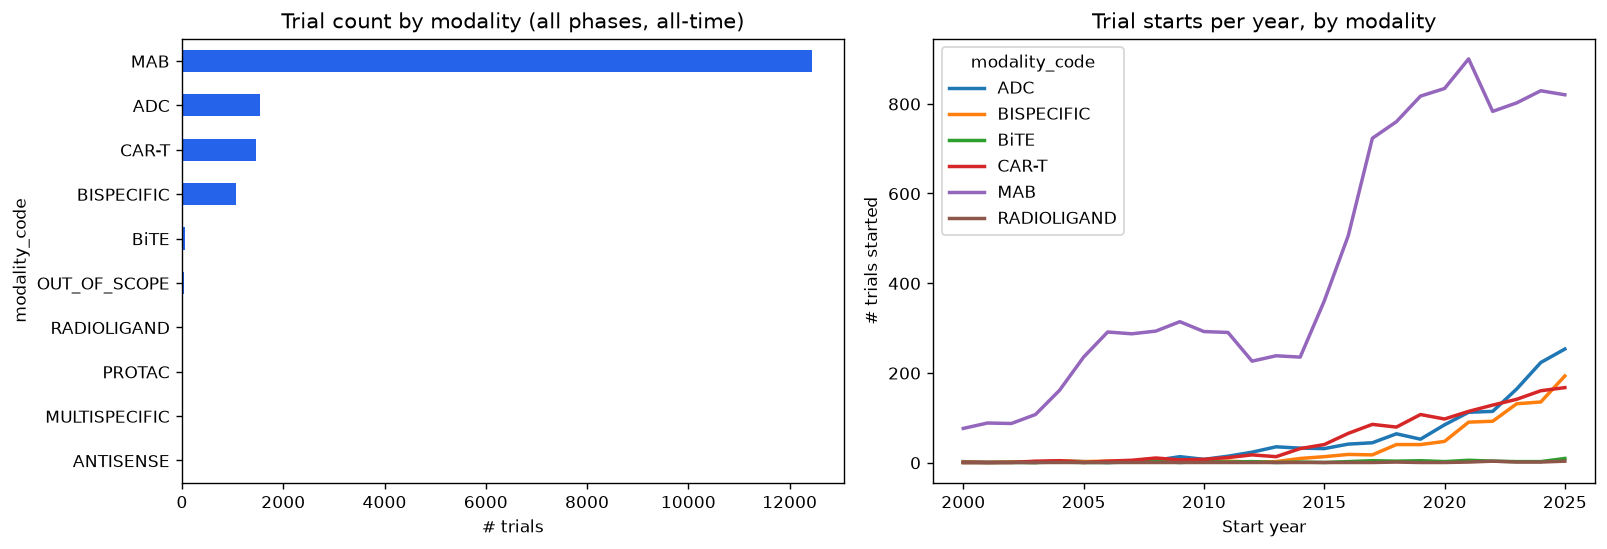

In [4]:
q = con.sql('''
    SELECT modality_code, COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           COUNT(DISTINCT target_h) AS n_distinct_targets
    FROM trials GROUP BY 1 ORDER BY n_trials DESC
''').df()
display(q, name="entry04_modality_overview")

trend = con.sql('''
    SELECT start_year, modality_code, COUNT(*) AS n_trials
    FROM trials
    WHERE start_year BETWEEN 2000 AND 2025
      AND modality_code IN ('MAB','ADC','BISPECIFIC','CAR-T','BiTE','RADIOLIGAND')
    GROUP BY 1,2
''').df()
pivot = trend.pivot_table(index="start_year", columns="modality_code", values="n_trials", fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
q.set_index("modality_code")["n_trials"].sort_values().plot(kind="barh", ax=axes[0], color="#2563eb")
axes[0].set_title("Trial count by modality (all phases, all-time)")
axes[0].set_xlabel("# trials")

pivot.plot(ax=axes[1], linewidth=2)
axes[1].set_title("Trial starts per year, by modality")
axes[1].set_xlabel("Start year"); axes[1].set_ylabel("# trials started")
plt.tight_layout()

## Entry 5: Target Landscape Overview (Top 30 Targets by Clinical Activity)

In [5]:
q = con.sql('''
    SELECT target_h AS target_harmonized, COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           COUNT(DISTINCT modality_code) AS n_modalities,
           COUNT(DISTINCT nct) AS n_ncts
    FROM trials
    WHERE target_h IS NOT NULL
    GROUP BY 1 ORDER BY n_trials DESC LIMIT 30
''').df()
display(q, name="entry05_top30_targets")
print(f"Distinct target_harmonized values (incl. multi-target combos): {df['target_h'].nunique():,}")

Distinct target_harmonized values (incl. multi-target combos): 1,572


,target_harmonized,n_trials,n_sponsors,n_modalities,n_ncts
0,PD-1,2908,978,6,2829
1,HER2,1171,430,5,1158
2,VEGF,863,345,4,811
3,PD-L1,791,349,5,776
4,CD20,788,307,3,788
5,EGFR,738,339,6,701
6,PD-1|PD-L1,471,266,5,470
7,CD19,432,209,5,432
8,CTLA-4|PD-1,351,184,3,350
9,CD38,165,97,3,165


## Entry 6: Modality x Phase Funnel (Development-Stage Mix)

phase_canon,Phase 1,Phase 1/2,Phase 2,Phase 2/3,Phase 3,Phase 4,Unknown
modality_code,,,,,,,
ADC,348.0,245.0,591.0,21.0,179.0,21.0,145.0
BISPECIFIC,309.0,184.0,377.0,8.0,70.0,6.0,106.0
BiTE,25.0,5.0,20.0,1.0,2.0,1.0,9.0
CAR-T,844.0,356.0,136.0,6.0,6.0,1.0,115.0
MAB,2475.0,1558.0,5662.0,160.0,1310.0,106.0,1175.0
RADIOLIGAND,4.0,4.0,4.0,0.0,0.0,0.0,0.0


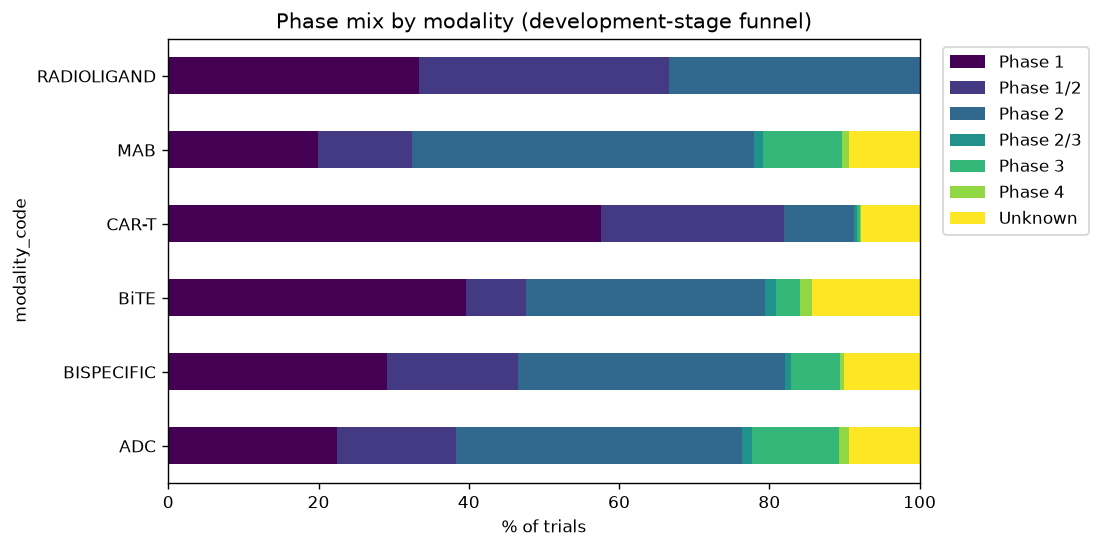

In [6]:
q = con.sql('''
    SELECT modality_code, phase_canon, COUNT(*) AS n
    FROM trials WHERE modality_code IN ('MAB','ADC','BISPECIFIC','CAR-T','BiTE','RADIOLIGAND')
    GROUP BY 1,2
''').df()
pivot = q.pivot_table(index="modality_code", columns="phase_canon", values="n", fill_value=0)
order = ["Phase 1", "Phase 1/2", "Phase 2", "Phase 2/3", "Phase 3", "Phase 4", "Unknown"]
pivot = pivot[[c for c in order if c in pivot.columns]]
display(pivot, name="entry06_modality_phase_counts")

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot_pct.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
ax.set_xlabel("% of trials"); ax.set_title("Phase mix by modality (development-stage funnel)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Entry 7: Target x Phase Matrix (Top 25 Targets)

phase_canon,Phase 1,Phase 1/2,Phase 2,Phase 2/3,Phase 3,Phase 4,Unknown
target_h,,,,,,,
PD-1,531,365,1371,37,278,23,303
HER2,151,90,498,17,174,24,217
VEGF,132,48,474,7,105,15,82
PD-L1,167,82,385,7,96,4,50
CD20,119,95,395,4,102,12,61
EGFR,141,83,364,15,64,6,65
PD-1|PD-L1,75,62,222,8,59,2,43
CD19,220,94,61,5,4,0,48
CTLA-4|PD-1,71,47,183,5,24,0,21


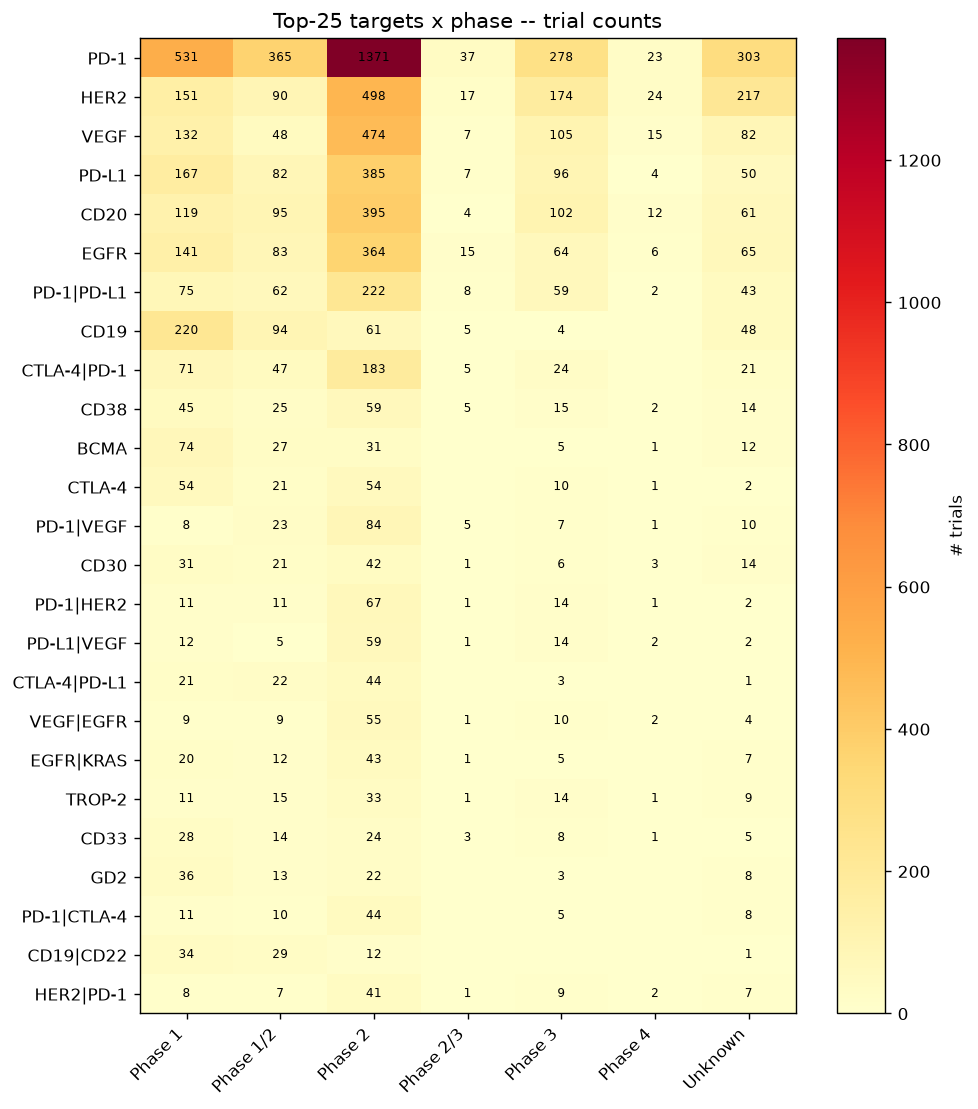

In [7]:
top25 = con.sql("SELECT target_h FROM trials WHERE target_h IS NOT NULL GROUP BY 1 ORDER BY COUNT(*) DESC LIMIT 25").df()["target_h"].tolist()
mat = df[df["target_h"].isin(top25)].pivot_table(index="target_h", columns="phase_canon", values="nct", aggfunc="count", fill_value=0)
mat = mat.reindex(top25)
order = ["Phase 1", "Phase 1/2", "Phase 2", "Phase 2/3", "Phase 3", "Phase 4", "Unknown"]
mat = mat[[c for c in order if c in mat.columns]]
display(mat, name="entry07_top25_target_phase_matrix")

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(mat.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7)
ax.set_title("Top-25 targets x phase -- trial counts")
plt.colorbar(im, ax=ax, label="# trials")
plt.tight_layout()

## Entry 8: Modality-Level Clinical Outcome Rates

outcome_bucket,Failure,Ongoing/Pending,Success,Unclear
modality_code,,,,
ADC,234.0,1074.0,146.0,96.0
BISPECIFIC,121.0,721.0,101.0,117.0
BiTE,17.0,37.0,2.0,7.0
CAR-T,160.0,890.0,19.0,395.0
MAB,2134.0,7426.0,1046.0,1840.0
RADIOLIGAND,3.0,8.0,0.0,1.0


outcome_bucket,Failure,Ongoing/Pending,Success,Unclear
modality_code,,,,
ADC,15.1,69.3,9.4,6.2
BISPECIFIC,11.4,68.0,9.5,11.0
BiTE,27.0,58.7,3.2,11.1
CAR-T,10.9,60.8,1.3,27.0
MAB,17.1,59.7,8.4,14.8
RADIOLIGAND,25.0,66.7,0.0,8.3


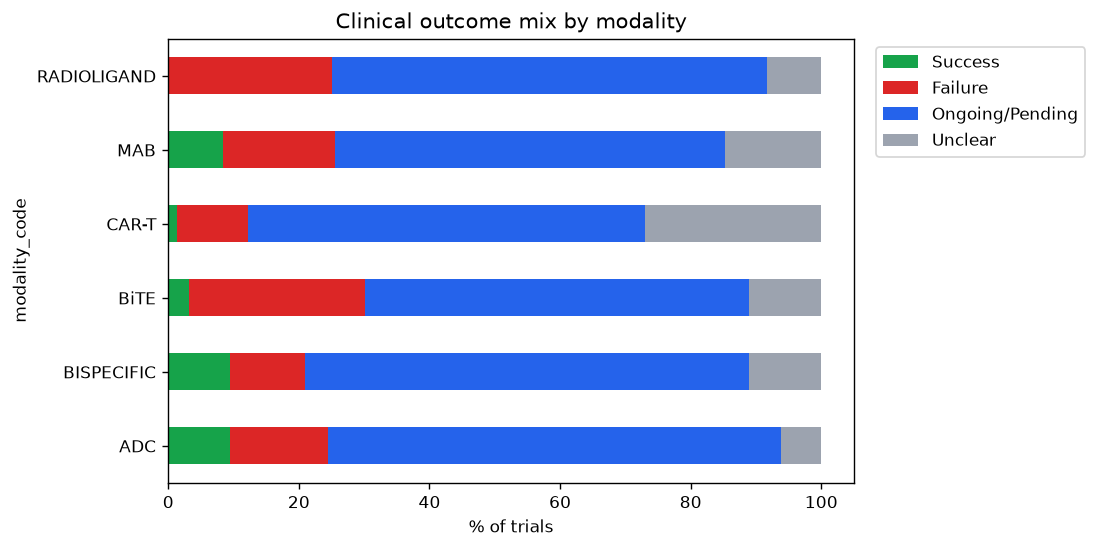

In [8]:
q = con.sql('''
    SELECT modality_code, outcome_bucket, COUNT(*) AS n
    FROM trials WHERE modality_code IN ('MAB','ADC','BISPECIFIC','CAR-T','BiTE','RADIOLIGAND')
    GROUP BY 1,2
''').df()
pivot = q.pivot_table(index="modality_code", columns="outcome_bucket", values="n", fill_value=0)
pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0) * 100).round(1)
display(pivot, name="entry08_modality_outcome_counts")
display(pivot_pct, name="entry08_modality_outcome_pct")

cols = [c for c in ["Success", "Failure", "Ongoing/Pending", "Unclear"] if c in pivot_pct.columns]
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot_pct[cols].plot(kind="barh", stacked=True, ax=ax, color=["#16a34a", "#dc2626", "#2563eb", "#9ca3af"])
ax.set_xlabel("% of trials"); ax.set_title("Clinical outcome mix by modality")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Entry 9: Target Validation Scorecard -- Succeeded / Failed / Still-in-Trial, by Phase

In [9]:
q = con.sql('''
    SELECT target_h AS target_harmonized,
           COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure,
           SUM(CASE WHEN outcome_bucket='Ongoing/Pending' THEN 1 ELSE 0 END) AS n_ongoing,
           SUM(CASE WHEN outcome_bucket='Unclear' THEN 1 ELSE 0 END) AS n_unclear,
           SUM(CASE WHEN phase_canon='Phase 1' THEN 1 ELSE 0 END) AS ph1,
           SUM(CASE WHEN phase_canon='Phase 1/2' THEN 1 ELSE 0 END) AS ph1_2,
           SUM(CASE WHEN phase_canon='Phase 2' THEN 1 ELSE 0 END) AS ph2,
           SUM(CASE WHEN phase_canon='Phase 2/3' THEN 1 ELSE 0 END) AS ph2_3,
           SUM(CASE WHEN phase_canon='Phase 3' THEN 1 ELSE 0 END) AS ph3,
           SUM(CASE WHEN phase_canon='Phase 4' THEN 1 ELSE 0 END) AS ph4,
           SUM(CASE WHEN outcome='approved' THEN 1 ELSE 0 END) AS n_approved,
           MAX(start_year) AS latest_start_year
    FROM trials
    WHERE target_h IS NOT NULL
    GROUP BY 1
    HAVING COUNT(*) >= 5
    ORDER BY n_trials DESC
''').df()
q["success_rate_%"] = (q["n_success"] / q["n_trials"] * 100).round(1)
q["failure_rate_%"] = (q["n_failure"] / q["n_trials"] * 100).round(1)

def target_status(row):
    if row["n_success"] > 0 and row["n_failure"] > 0:
        return "Mixed (succeeded & failed)"
    if row["n_success"] > 0:
        return "Validated (success recorded)"
    if row["n_failure"] > 0:
        return "Failed only (no success yet)"
    return "Still-in-trial (no readout yet)"

q["target_status"] = q.apply(target_status, axis=1)
TARGET_SCORECARD = q
display(q, name="entry09_target_outcome_scorecard")
print(f"\n{len(q)} targets have >=5 trials. Status breakdown:")
display(q["target_status"].value_counts().to_frame("n_targets"), name="entry09_target_status_summary")


243 targets have >=5 trials. Status breakdown:


,target_harmonized,n_trials,n_success,n_failure,n_ongoing,n_unclear,ph1,ph1_2,ph2,ph2_3,ph3,ph4,n_approved,latest_start_year,success_rate_%,failure_rate_%,target_status
0,PD-1,2908,350.0,365.0,1562.0,631.0,531.0,365.0,1371.0,37.0,278.0,23.0,274.0,2027.0,12.0,12.6,Mixed (succeeded & failed)
1,HER2,1171,69.0,156.0,774.0,172.0,151.0,90.0,498.0,17.0,174.0,24.0,3.0,2027.0,5.9,13.3,Mixed (succeeded & failed)
2,VEGF,863,224.0,125.0,423.0,91.0,132.0,48.0,474.0,7.0,105.0,15.0,201.0,2026.0,26.0,14.5,Mixed (succeeded & failed)
3,PD-L1,791,81.0,138.0,479.0,93.0,167.0,82.0,385.0,7.0,96.0,4.0,64.0,2027.0,10.2,17.4,Mixed (succeeded & failed)
4,CD20,788,33.0,156.0,521.0,78.0,119.0,95.0,395.0,4.0,102.0,12.0,0.0,2026.0,4.2,19.8,Mixed (succeeded & failed)
5,EGFR,738,16.0,202.0,390.0,130.0,141.0,83.0,364.0,15.0,64.0,6.0,6.0,2027.0,2.2,27.4,Mixed (succeeded & failed)
6,PD-1|PD-L1,471,22.0,70.0,271.0,108.0,75.0,62.0,222.0,8.0,59.0,2.0,1.0,2026.0,4.7,14.9,Mixed (succeeded & failed)
7,CD19,432,11.0,37.0,252.0,132.0,220.0,94.0,61.0,5.0,4.0,0.0,1.0,2026.0,2.5,8.6,Mixed (succeeded & failed)
8,CTLA-4|PD-1,351,16.0,54.0,248.0,33.0,71.0,47.0,183.0,5.0,24.0,0.0,0.0,2026.0,4.6,15.4,Mixed (succeeded & failed)
9,CD38,165,7.0,34.0,106.0,18.0,45.0,25.0,59.0,5.0,15.0,2.0,0.0,2027.0,4.2,20.6,Mixed (succeeded & failed)


,n_targets
target_status,
Mixed (succeeded & failed),99
Failed only (no success yet),83
Still-in-trial (no readout yet),40
Validated (success recorded),21


## Entry 10: Chart -- Top-25 Targets, Outcome Composition

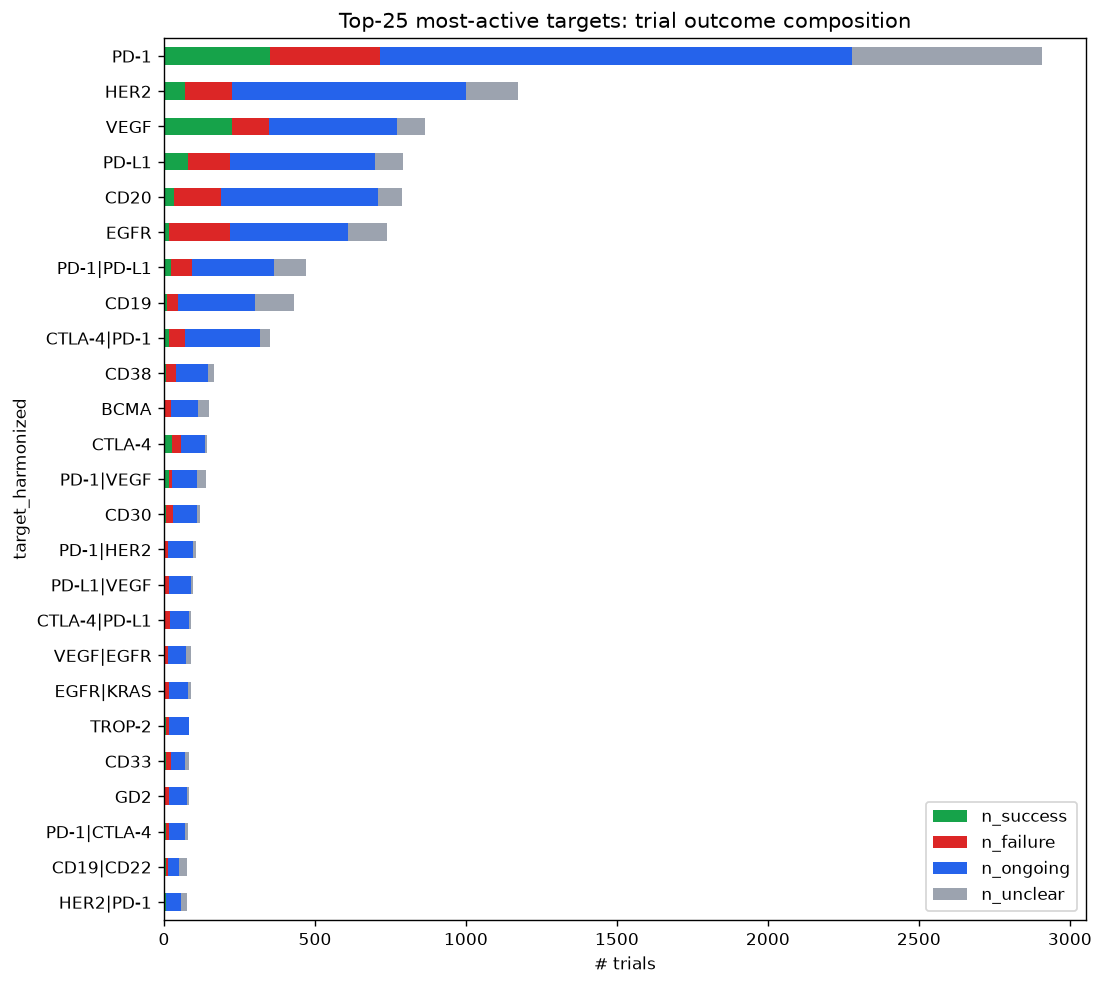

In [10]:
plot_df = TARGET_SCORECARD.sort_values("n_trials", ascending=False).head(25).set_index("target_harmonized")
plot_df = plot_df[["n_success", "n_failure", "n_ongoing", "n_unclear"]].iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
plot_df.plot(kind="barh", stacked=True, ax=ax, color=["#16a34a", "#dc2626", "#2563eb", "#9ca3af"])
ax.set_xlabel("# trials"); ax.set_title("Top-25 most-active targets: trial outcome composition")
ax.legend(loc="lower right")
plt.tight_layout()

## Entry 11: Target x Modality Crowding Matrix (Top 20 Targets)

modality_code,ADC,ANTISENSE,BISPECIFIC,BiTE,CAR-T,MAB,OUT_OF_SCOPE,PROTAC
target_h,,,,,,,,
PD-1,6,0,14,1,29,2850,8,0
HER2,222,0,27,0,17,904,0,1
VEGF,0,0,7,0,1,854,1,0
PD-L1,2,0,10,0,3,769,7,0
CD20,0,0,7,0,14,767,0,0
EGFR,10,1,21,0,16,689,1,0
PD-1|PD-L1,0,0,8,0,3,455,4,1
CD19,1,0,1,2,393,35,0,0
CTLA-4|PD-1,0,0,75,0,2,274,0,0


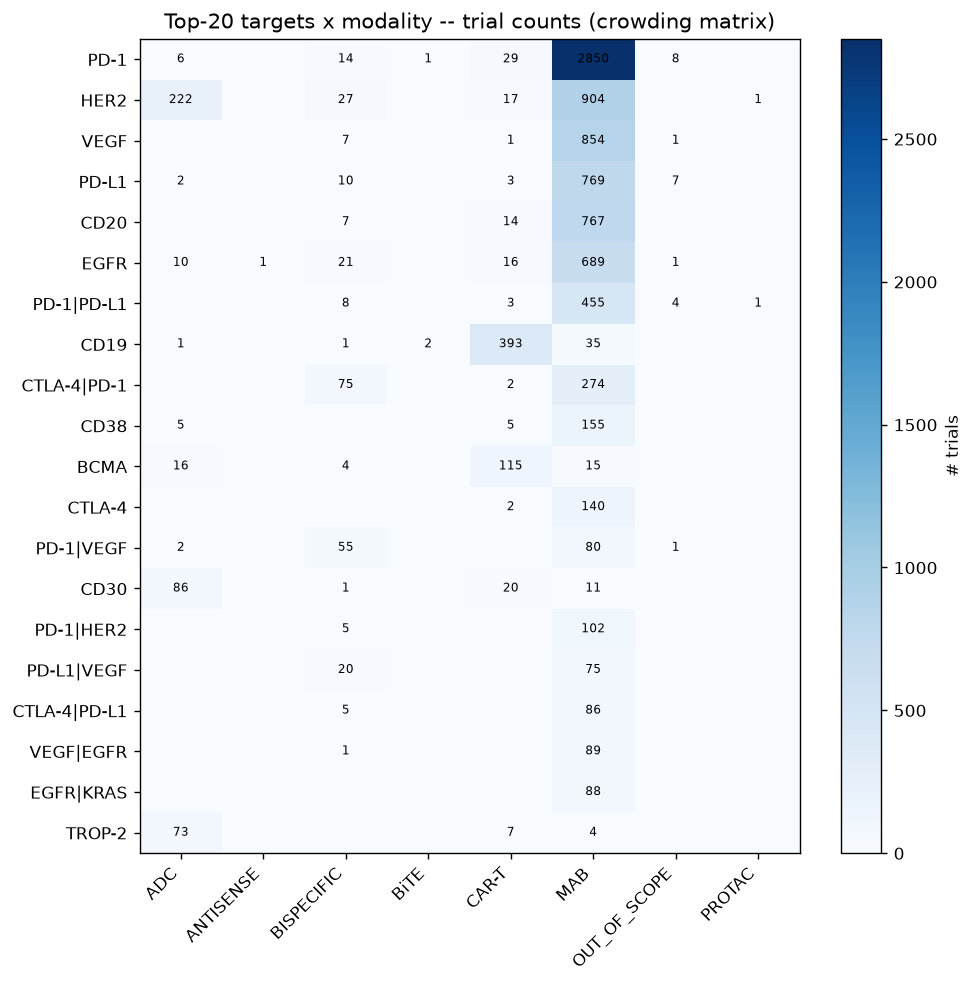

In [11]:
top20 = TARGET_SCORECARD.sort_values("n_trials", ascending=False).head(20)["target_harmonized"].tolist()
mat = df[df["target_h"].isin(top20)].pivot_table(index="target_h", columns="modality_code", values="nct", aggfunc="count", fill_value=0)
mat = mat.reindex(top20)
display(mat, name="entry11_target_modality_matrix")

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(mat.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7)
ax.set_title("Top-20 targets x modality -- trial counts (crowding matrix)")
plt.colorbar(im, ax=ax, label="# trials")
plt.tight_layout()

## Entry 12: Solid-Tumor-Type x Modality Landscape

modality_code,ADC,ANTISENSE,BISPECIFIC,BiTE,CAR-T,MAB,MULTISPECIFIC,OUT_OF_SCOPE,PROTAC,RADIOLIGAND,Total
tumor_type,,,,,,,,,,,
Lung_Other,305.0,0.0,211.0,12.0,71.0,2298.0,1.0,38.0,0.0,3.0,2939.0
NSCLC,263.0,0.0,187.0,6.0,31.0,1859.0,2.0,6.0,0.0,1.0,2355.0
Breast,406.0,0.0,64.0,2.0,49.0,1578.0,1.0,8.0,4.0,2.0,2114.0
SCLC,229.0,0.0,180.0,7.0,40.0,1590.0,1.0,13.0,0.0,1.0,2061.0
Colorectal,56.0,0.0,85.0,2.0,55.0,1251.0,1.0,1.0,0.0,2.0,1453.0
Gastric_Esophageal,122.0,0.0,83.0,3.0,57.0,821.0,0.0,5.0,0.0,2.0,1093.0
HNSCC,62.0,1.0,54.0,1.0,7.0,788.0,1.0,5.0,0.0,1.0,920.0
Melanoma,27.0,0.0,31.0,2.0,41.0,666.0,0.0,7.0,0.0,0.0,774.0
Pancreatic,59.0,0.0,41.0,2.0,66.0,460.0,0.0,2.0,0.0,1.0,631.0


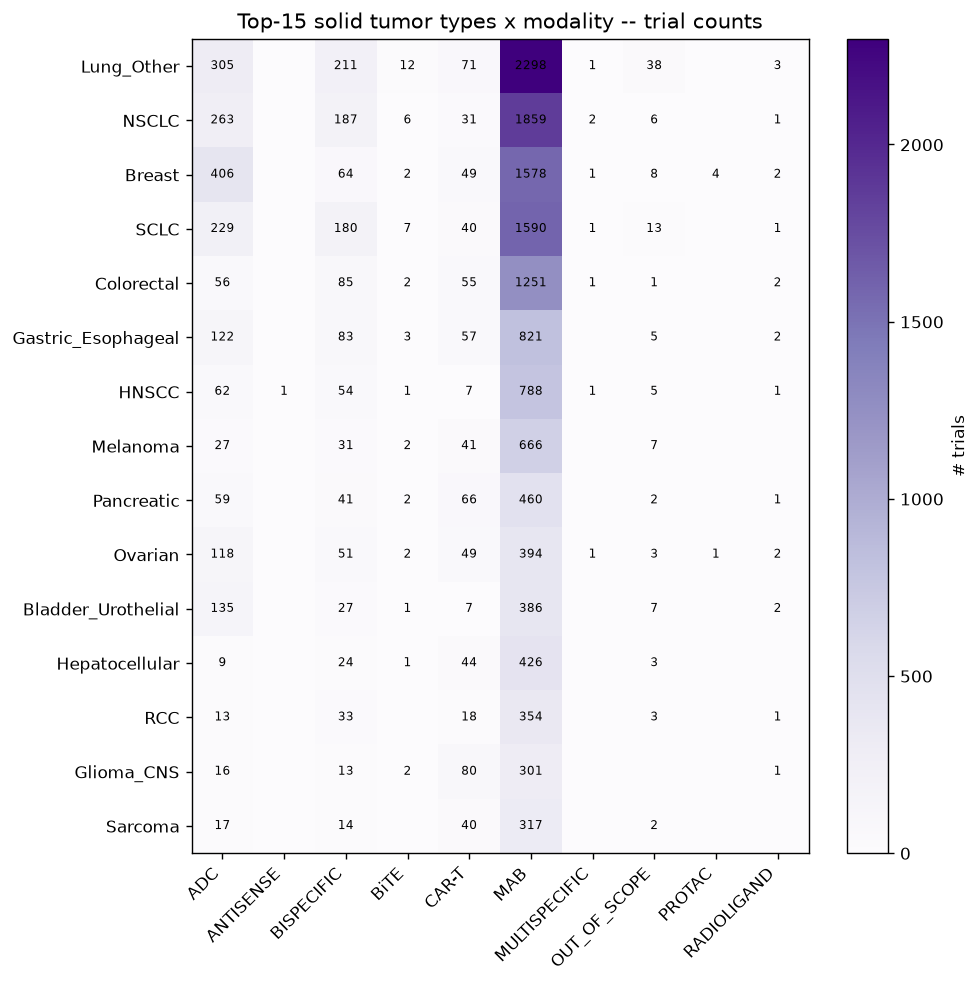

In [12]:
q = con.sql('''
    SELECT tumor_type, modality_code, COUNT(*) AS n_trials
    FROM tumor_junction
    WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket'
    GROUP BY 1,2
''').df()
pivot = q.pivot_table(index="tumor_type", columns="modality_code", values="n_trials", fill_value=0)
pivot["Total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("Total", ascending=False)
display(pivot, name="entry12_tumor_modality_matrix")

top15 = pivot.head(15).drop(columns="Total")
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(top15.values, cmap="Purples", aspect="auto")
ax.set_xticks(range(len(top15.columns))); ax.set_xticklabels(top15.columns, rotation=45, ha="right")
ax.set_yticks(range(len(top15.index))); ax.set_yticklabels(top15.index)
for i in range(top15.shape[0]):
    for j in range(top15.shape[1]):
        v = top15.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7)
ax.set_title("Top-15 solid tumor types x modality -- trial counts")
plt.colorbar(im, ax=ax, label="# trials")
plt.tight_layout()

## Entry 13: Top Targets per Solid Tumor Type

In [13]:
q = con.sql('''
    WITH agg AS (
      SELECT tumor_type, target_h AS target_harmonized, COUNT(*) AS n_trials
      FROM tumor_junction
      WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket' AND target_h IS NOT NULL
      GROUP BY 1,2
    ), ranked AS (
      SELECT *, ROW_NUMBER() OVER (PARTITION BY tumor_type ORDER BY n_trials DESC) AS rnk,
             SUM(n_trials) OVER (PARTITION BY tumor_type) AS tumor_total
      FROM agg
    )
    SELECT tumor_type, target_harmonized, n_trials, tumor_total FROM ranked
    WHERE rnk <= 5 AND tumor_total >= 20
    ORDER BY tumor_total DESC, n_trials DESC
''').df()
display(q, name="entry13_top_targets_per_tumor_type")

,tumor_type,target_harmonized,n_trials,tumor_total
0,Lung_Other,PD-1,678,2853.0
1,Lung_Other,PD-L1,277,2853.0
2,Lung_Other,VEGF,272,2853.0
3,Lung_Other,EGFR,183,2853.0
4,Lung_Other,PD-1|PD-L1,146,2853.0
5,NSCLC,PD-1,562,2283.0
6,NSCLC,PD-L1,195,2283.0
7,NSCLC,VEGF,186,2283.0
8,NSCLC,EGFR,149,2283.0
9,NSCLC,PD-1|PD-L1,129,2283.0


## Entry 14: Chart -- Top Targets per Solid Tumor Type (Small Multiples)

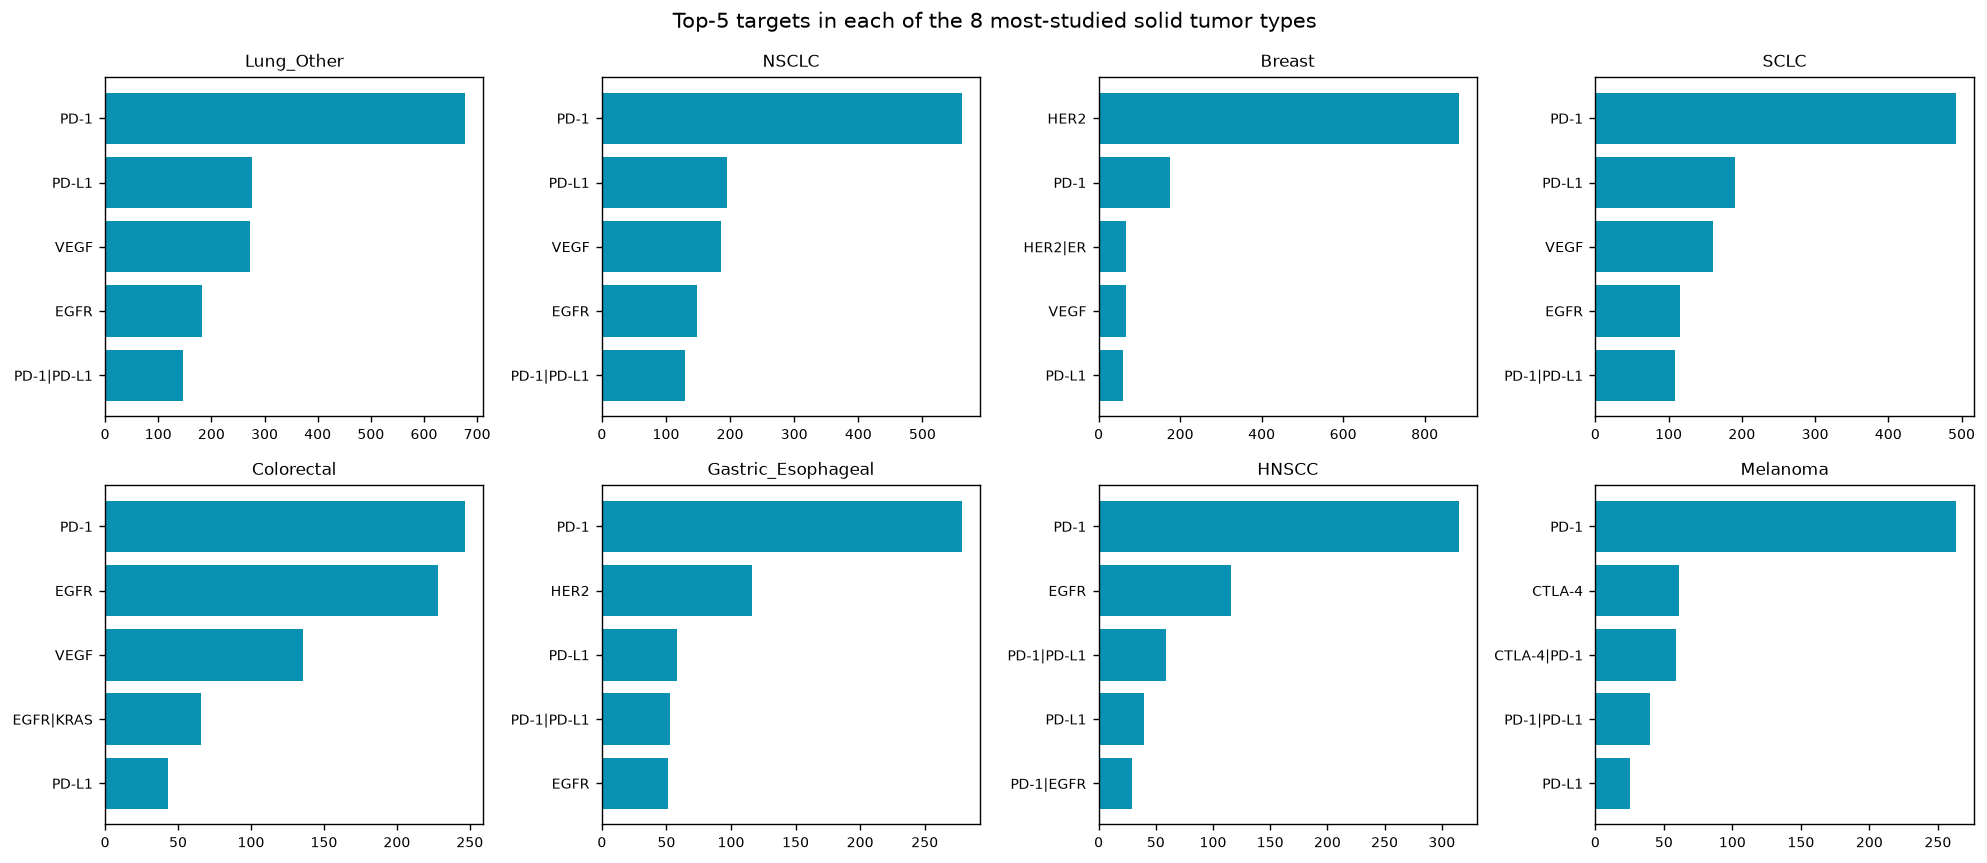

In [14]:
q = con.sql('''
    WITH agg AS (
      SELECT tumor_type, target_h AS target_harmonized, COUNT(*) AS n_trials
      FROM tumor_junction
      WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket' AND target_h IS NOT NULL
      GROUP BY 1,2
    ), ranked AS (
      SELECT *, ROW_NUMBER() OVER (PARTITION BY tumor_type ORDER BY n_trials DESC) AS rnk,
             SUM(n_trials) OVER (PARTITION BY tumor_type) AS tumor_total
      FROM agg
    )
    SELECT tumor_type, target_harmonized, n_trials, tumor_total FROM ranked
    WHERE rnk <= 5 AND tumor_total >= 20
    ORDER BY tumor_total DESC, n_trials DESC
''').df()
top_tumors = q.drop_duplicates("tumor_type").sort_values("tumor_total", ascending=False)["tumor_type"].head(8).tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, tt in zip(axes.flat, top_tumors):
    sub = q[q["tumor_type"] == tt].sort_values("n_trials")
    ax.barh(sub["target_harmonized"], sub["n_trials"], color="#0891b2")
    ax.set_title(tt, fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle("Top-5 targets in each of the 8 most-studied solid tumor types")
plt.tight_layout()

## Entry 15: Per-Tumor-Type Target Outcome Scorecard (Solid Tumors)

In [15]:
q = con.sql('''
    SELECT tumor_type, target_h AS target_harmonized,
           COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure,
           SUM(CASE WHEN outcome_bucket='Ongoing/Pending' THEN 1 ELSE 0 END) AS n_ongoing
    FROM tumor_junction
    WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket' AND target_h IS NOT NULL
    GROUP BY 1,2
    HAVING COUNT(*) >= 3
    ORDER BY n_trials DESC
''').df()
TUMOR_TARGET_SCORECARD = q
display(q.head(50), name="entry15_tumor_target_outcome")
print(f"{len(q)} target x solid-tumor-type combinations with >=3 trials (full table exported to CSV).")

748 target x solid-tumor-type combinations with >=3 trials (full table exported to CSV).


,tumor_type,target_harmonized,n_trials,n_success,n_failure,n_ongoing
0,Breast,HER2,884,57.0,118.0,599.0
1,Lung_Other,PD-1,678,265.0,81.0,237.0
2,NSCLC,PD-1,562,233.0,62.0,191.0
3,SCLC,PD-1,492,200.0,60.0,161.0
4,HNSCC,PD-1,315,29.0,42.0,197.0
5,Gastric_Esophageal,PD-1,279,21.0,25.0,160.0
6,Lung_Other,PD-L1,277,65.0,44.0,149.0
7,Lung_Other,VEGF,272,191.0,18.0,45.0
8,Melanoma,PD-1,263,39.0,53.0,126.0
9,Colorectal,PD-1,247,21.0,34.0,149.0


## Entry 16: Regimen-Dependent Divergence -- Same Target, IO-Combo vs Monotherapy

In [16]:
# "Same target succeeded with IO but failed as an all-comers monotherapy"
def regimen_bucket(is_combo, partner_class):
    ic = str(is_combo)
    if ic == "True":
        pc = str(partner_class) if pd.notna(partner_class) else ""
        return "IO-combo" if "IO" in pc else "Non-IO-combo (chemo/TKI/other)"
    if ic == "False":
        return "Monotherapy"
    return "Unknown regimen"

df["regimen_bucket"] = [regimen_bucket(a, b) for a, b in zip(df["is_combo"], df["combo_partner_class"])]
con.register("trials", df)

q = con.sql('''
    SELECT target_h AS target_harmonized, regimen_bucket,
           COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure
    FROM trials
    WHERE target_h IS NOT NULL AND regimen_bucket IN ('IO-combo','Monotherapy')
    GROUP BY 1,2
''').df()
piv_t = q.pivot_table(index="target_harmonized", columns="regimen_bucket", values="n_trials", fill_value=0)
piv_s = q.pivot_table(index="target_harmonized", columns="regimen_bucket", values="n_success", fill_value=0)
piv_f = q.pivot_table(index="target_harmonized", columns="regimen_bucket", values="n_failure", fill_value=0)

divergence = pd.DataFrame({
    "n_trials_IO_combo": piv_t.get("IO-combo", 0), "n_success_IO_combo": piv_s.get("IO-combo", 0), "n_failure_IO_combo": piv_f.get("IO-combo", 0),
    "n_trials_mono": piv_t.get("Monotherapy", 0), "n_success_mono": piv_s.get("Monotherapy", 0), "n_failure_mono": piv_f.get("Monotherapy", 0),
}).fillna(0)
divergence = divergence[(divergence["n_trials_IO_combo"] >= 2) & (divergence["n_trials_mono"] >= 2)]
divergence["divergence_flag"] = np.where(
    (divergence["n_success_IO_combo"] > 0) & (divergence["n_failure_mono"] > 0) & (divergence["n_success_mono"] == 0),
    "IO-combo succeeds, monotherapy fails",
    np.where(
        (divergence["n_success_mono"] > 0) & (divergence["n_failure_IO_combo"] > 0) & (divergence["n_success_IO_combo"] == 0),
        "Monotherapy succeeds, IO-combo fails", "No clear divergence"))
REGIMEN_DIVERGENCE = divergence.sort_values("n_trials_IO_combo", ascending=False)
display(REGIMEN_DIVERGENCE, name="entry16_regimen_divergence")

flagged = REGIMEN_DIVERGENCE[REGIMEN_DIVERGENCE["divergence_flag"] != "No clear divergence"]
print(f"\n{len(flagged)} targets show a regimen-dependent outcome divergence (IO-combo vs monotherapy), "
      f"out of {len(REGIMEN_DIVERGENCE)} targets with >=2 trials in both arms.")
display(flagged, name="entry16_regimen_divergence_flagged")


1 targets show a regimen-dependent outcome divergence (IO-combo vs monotherapy), out of 12 targets with >=2 trials in both arms.


,n_trials_IO_combo,n_success_IO_combo,n_failure_IO_combo,n_trials_mono,n_success_mono,n_failure_mono,divergence_flag
target_harmonized,,,,,,,
PD-1,54.0,52.0,1.0,111.0,88.0,5.0,No clear divergence
PD-L1,14.0,13.0,1.0,39.0,23.0,5.0,No clear divergence
EGFR,6.0,0.0,6.0,24.0,0.0,23.0,No clear divergence
TROP-2-SN38,5.0,0.0,5.0,4.0,0.0,4.0,No clear divergence
TIGIT,4.0,0.0,3.0,2.0,0.0,2.0,No clear divergence
HER2,3.0,1.0,2.0,6.0,0.0,6.0,"IO-combo succeeds, monotherapy fails"
HER2-Dxd,3.0,3.0,0.0,5.0,5.0,0.0,No clear divergence
VEGF,3.0,2.0,0.0,28.0,24.0,2.0,No clear divergence
VEGFR2,3.0,3.0,0.0,4.0,2.0,1.0,No clear divergence


,n_trials_IO_combo,n_success_IO_combo,n_failure_IO_combo,n_trials_mono,n_success_mono,n_failure_mono,divergence_flag
target_harmonized,,,,,,,
HER2,3.0,1.0,2.0,6.0,0.0,6.0,"IO-combo succeeds, monotherapy fails"


## Entry 17: Chart -- IO-Combo vs Monotherapy Success-Rate Divergence

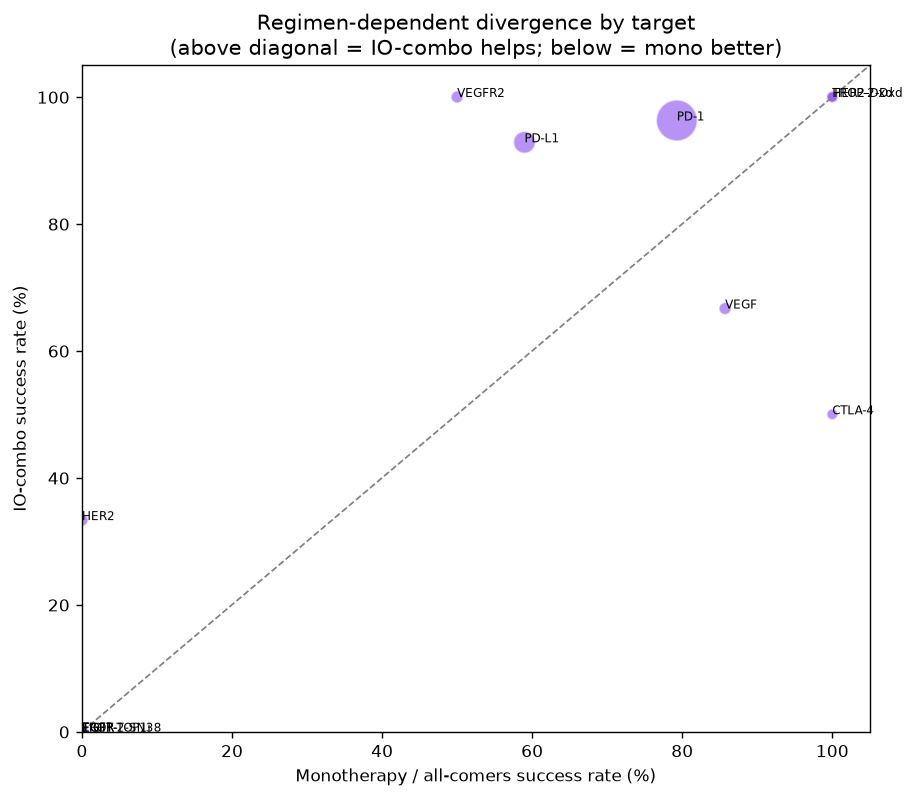

In [17]:
plot_df = REGIMEN_DIVERGENCE.copy()
plot_df["success_rate_IO"] = plot_df["n_success_IO_combo"] / plot_df["n_trials_IO_combo"] * 100
plot_df["success_rate_mono"] = plot_df["n_success_mono"] / plot_df["n_trials_mono"] * 100

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(plot_df["success_rate_mono"], plot_df["success_rate_IO"],
           s=plot_df["n_trials_IO_combo"] * 10 + 20, alpha=0.55, c="#7c3aed", edgecolor="white")
for name, row in plot_df.iterrows():
    ax.annotate(name, (row["success_rate_mono"], row["success_rate_IO"]), fontsize=7)
top_lim = max(plot_df["success_rate_mono"].max(), plot_df["success_rate_IO"].max(), 10) + 5
ax.plot([0, top_lim], [0, top_lim], "--", color="gray", linewidth=1)
ax.set_xlim(0, top_lim); ax.set_ylim(0, top_lim)
ax.set_xlabel("Monotherapy / all-comers success rate (%)")
ax.set_ylabel("IO-combo success rate (%)")
ax.set_title("Regimen-dependent divergence by target\n(above diagonal = IO-combo helps; below = mono better)")
plt.tight_layout()

## Entry 18: Modality-Dependent Divergence -- Same Target, Naked mAb vs ADC

In [18]:
# "Failed as mono[clonal antibody] but succeeded as an ADC" (or vice versa)
q = con.sql('''
    SELECT target_h AS target_harmonized, modality_code,
           COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure
    FROM trials
    WHERE target_h IS NOT NULL AND modality_code IN ('MAB','ADC')
    GROUP BY 1,2
''').df()
piv_t = q.pivot_table(index="target_harmonized", columns="modality_code", values="n_trials", fill_value=0)
piv_s = q.pivot_table(index="target_harmonized", columns="modality_code", values="n_success", fill_value=0)
piv_f = q.pivot_table(index="target_harmonized", columns="modality_code", values="n_failure", fill_value=0)

mod_div = pd.DataFrame({
    "n_trials_MAB": piv_t.get("MAB", 0), "n_success_MAB": piv_s.get("MAB", 0), "n_failure_MAB": piv_f.get("MAB", 0),
    "n_trials_ADC": piv_t.get("ADC", 0), "n_success_ADC": piv_s.get("ADC", 0), "n_failure_ADC": piv_f.get("ADC", 0),
}).fillna(0)
mod_div = mod_div[(mod_div["n_trials_MAB"] >= 2) & (mod_div["n_trials_ADC"] >= 2)]
mod_div["divergence_flag"] = np.where(
    (mod_div["n_success_ADC"] > 0) & (mod_div["n_failure_MAB"] > 0) & (mod_div["n_success_MAB"] == 0),
    "ADC succeeds, naked mAb fails",
    np.where((mod_div["n_success_MAB"] > 0) & (mod_div["n_failure_ADC"] > 0) & (mod_div["n_success_ADC"] == 0),
             "Naked mAb succeeds, ADC fails", "No clear divergence"))
MODALITY_DIVERGENCE = mod_div.sort_values("n_trials_ADC", ascending=False)
display(MODALITY_DIVERGENCE, name="entry18_modality_divergence")

flagged2 = MODALITY_DIVERGENCE[MODALITY_DIVERGENCE["divergence_flag"] != "No clear divergence"]
print(f"\n{len(flagged2)} targets show a modality-dependent outcome divergence (naked mAb vs ADC), "
      f"out of {len(MODALITY_DIVERGENCE)} targets with >=2 trials in both modalities.")
display(flagged2, name="entry18_modality_divergence_flagged")


14 targets show a modality-dependent outcome divergence (naked mAb vs ADC), out of 39 targets with >=2 trials in both modalities.


,n_trials_MAB,n_success_MAB,n_failure_MAB,n_trials_ADC,n_success_ADC,n_failure_ADC,divergence_flag
target_harmonized,,,,,,,
HER2,904.0,47.0,134.0,222.0,15.0,17.0,No clear divergence
CD30,11.0,2.0,1.0,86.0,5.0,17.0,No clear divergence
TROP-2,4.0,1.0,0.0,73.0,5.0,10.0,No clear divergence
HER2|PD-1,27.0,4.0,0.0,44.0,2.0,1.0,No clear divergence
NECTIN4,4.0,0.0,1.0,29.0,4.0,2.0,"ADC succeeds, naked mAb fails"
FOLR1,4.0,1.0,0.0,23.0,1.0,5.0,No clear divergence
CD30|PD-1,2.0,1.0,0.0,21.0,0.0,2.0,"Naked mAb succeeds, ADC fails"
BCMA,15.0,2.0,3.0,16.0,2.0,3.0,No clear divergence
CD22,21.0,2.0,8.0,14.0,4.0,3.0,No clear divergence


,n_trials_MAB,n_success_MAB,n_failure_MAB,n_trials_ADC,n_success_ADC,n_failure_ADC,divergence_flag
target_harmonized,,,,,,,
NECTIN4,4.0,0.0,1.0,29.0,4.0,2.0,"ADC succeeds, naked mAb fails"
CD30|PD-1,2.0,1.0,0.0,21.0,0.0,2.0,"Naked mAb succeeds, ADC fails"
CD33,52.0,5.0,11.0,14.0,0.0,3.0,"Naked mAb succeeds, ADC fails"
HER3,15.0,2.0,5.0,11.0,0.0,2.0,"Naked mAb succeeds, ADC fails"
HER2|PD-L1,17.0,0.0,2.0,11.0,1.0,2.0,"ADC succeeds, naked mAb fails"
HER2|VEGF,27.0,0.0,5.0,6.0,1.0,0.0,"ADC succeeds, naked mAb fails"
PD-1,2850.0,349.0,357.0,6.0,0.0,3.0,"Naked mAb succeeds, ADC fails"
HER2|ER,65.0,3.0,12.0,5.0,0.0,1.0,"Naked mAb succeeds, ADC fails"
CD38,155.0,7.0,31.0,5.0,0.0,2.0,"Naked mAb succeeds, ADC fails"


## Entry 19: Chart -- Naked mAb vs ADC Success-Rate Divergence

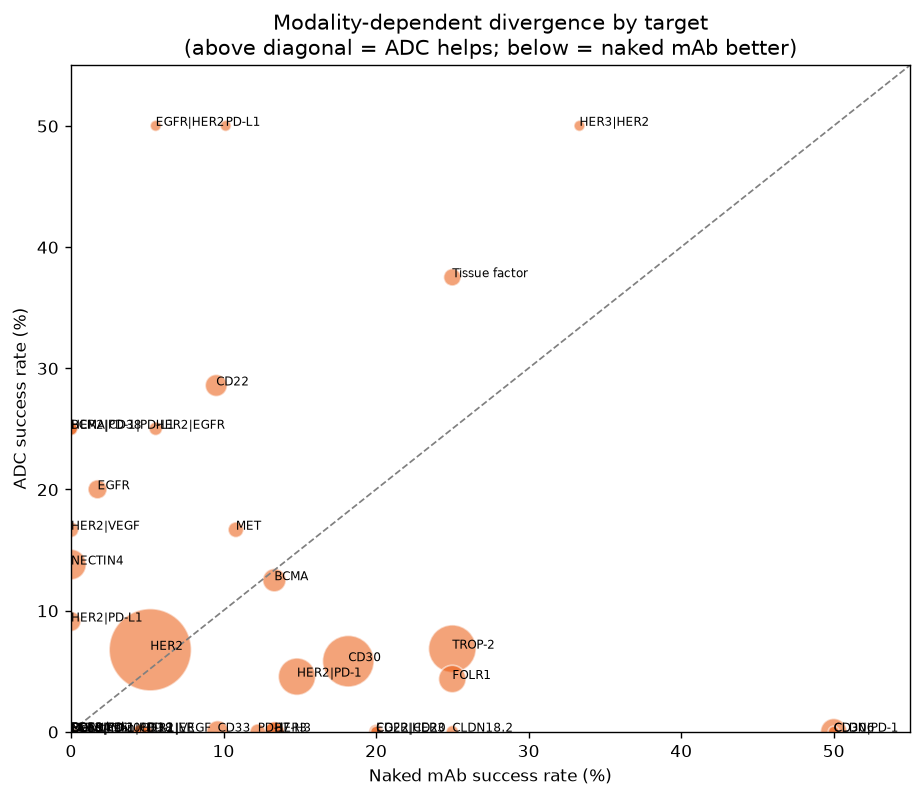

In [19]:
plot_df = MODALITY_DIVERGENCE.copy()
plot_df["success_rate_MAB"] = plot_df["n_success_MAB"] / plot_df["n_trials_MAB"] * 100
plot_df["success_rate_ADC"] = plot_df["n_success_ADC"] / plot_df["n_trials_ADC"] * 100

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(plot_df["success_rate_MAB"], plot_df["success_rate_ADC"],
           s=plot_df["n_trials_ADC"] * 10 + 20, alpha=0.55, c="#ea580c", edgecolor="white")
for name, row in plot_df.iterrows():
    ax.annotate(name, (row["success_rate_MAB"], row["success_rate_ADC"]), fontsize=7)
top_lim = max(plot_df["success_rate_MAB"].max(), plot_df["success_rate_ADC"].max(), 10) + 5
ax.plot([0, top_lim], [0, top_lim], "--", color="gray", linewidth=1)
ax.set_xlim(0, top_lim); ax.set_ylim(0, top_lim)
ax.set_xlabel("Naked mAb success rate (%)")
ax.set_ylabel("ADC success rate (%)")
ax.set_title("Modality-dependent divergence by target\n(above diagonal = ADC helps; below = naked mAb better)")
plt.tight_layout()

## Entry 20: Line-of-Therapy Divergence -- Same Target, 1L vs 2L+

In [20]:
q = con.sql('''
    SELECT target_h AS target_harmonized, m_line_of_therapy,
           COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure
    FROM trials
    WHERE target_h IS NOT NULL AND m_line_of_therapy IN ('1L','2L')
    GROUP BY 1,2
''').df()
piv_t = q.pivot_table(index="target_harmonized", columns="m_line_of_therapy", values="n_trials", fill_value=0)
piv_s = q.pivot_table(index="target_harmonized", columns="m_line_of_therapy", values="n_success", fill_value=0)
piv_f = q.pivot_table(index="target_harmonized", columns="m_line_of_therapy", values="n_failure", fill_value=0)

lot_div = pd.DataFrame({
    "n_trials_1L": piv_t.get("1L", 0), "n_success_1L": piv_s.get("1L", 0), "n_failure_1L": piv_f.get("1L", 0),
    "n_trials_2L": piv_t.get("2L", 0), "n_success_2L": piv_s.get("2L", 0), "n_failure_2L": piv_f.get("2L", 0),
}).fillna(0)
lot_div = lot_div[(lot_div["n_trials_1L"] >= 1) & (lot_div["n_trials_2L"] >= 1)]
lot_div = lot_div.sort_values(["n_trials_1L", "n_trials_2L"], ascending=False)
display(lot_div, name="entry20_line_of_therapy_divergence")
print(f"{len(lot_div)} targets have annotated activity in both 1L and 2L+ settings "
      f"(m_line_of_therapy is sparsely populated: {df['m_line_of_therapy'].notna().sum():,}/{len(df):,} rows).")

112 targets have annotated activity in both 1L and 2L+ settings (m_line_of_therapy is sparsely populated: 3,167/16,648 rows).


,n_trials_1L,n_success_1L,n_failure_1L,n_trials_2L,n_success_2L,n_failure_2L
target_harmonized,,,,,,
PD-1,188.0,5.0,23.0,175.0,6.0,20.0
CD20,130.0,9.0,19.0,187.0,3.0,58.0
HER2,69.0,3.0,9.0,50.0,3.0,12.0
VEGF,66.0,3.0,14.0,36.0,3.0,7.0
PD-L1,57.0,3.0,8.0,35.0,2.0,10.0
PD-1|PD-L1,55.0,1.0,5.0,35.0,1.0,3.0
EGFR,53.0,1.0,11.0,24.0,1.0,6.0
CTLA-4|PD-1,37.0,1.0,2.0,27.0,1.0,8.0
CD20|BTK,27.0,0.0,4.0,14.0,1.0,3.0


## Entry 21: Sponsor Concentration & Competitive Intensity per Target

In [21]:
q = con.sql('''
    SELECT target_h AS target_harmonized, lead_sponsor_golden, COUNT(*) AS n
    FROM trials WHERE target_h IS NOT NULL AND lead_sponsor_golden IS NOT NULL
    GROUP BY 1,2
''').df()
rows = []
for target, g in q.groupby("target_harmonized"):
    shares = g["n"] / g["n"].sum()
    rows.append({
        "target_harmonized": target,
        "n_trials": int(g["n"].sum()),
        "n_sponsors": int(g["lead_sponsor_golden"].nunique()),
        "top_sponsor": g.loc[g["n"].idxmax(), "lead_sponsor_golden"],
        "top_sponsor_share_%": round(shares.max() * 100, 1),
        "hhi": round((shares ** 2).sum() * 10000, 0),
    })
conc = pd.DataFrame(rows)
conc = conc[conc["n_trials"] >= 5].sort_values("n_trials", ascending=False)
SPONSOR_CONCENTRATION = conc
display(conc.head(40), name="entry21_sponsor_concentration")
print("HHI > 2500 = highly concentrated (single-sponsor-dominated); HHI < 1500 = fragmented/competitive field.")

HHI > 2500 = highly concentrated (single-sponsor-dominated); HHI < 1500 = fragmented/competitive field.


,target_harmonized,n_trials,n_sponsors,top_sponsor,top_sponsor_share_%,hhi
993,PD-1,2903,978,Merck Sharp & Dohme LLC,5.0,86.0
752,HER2,1150,430,Hoffmann-La Roche,7.5,128.0
1465,VEGF,862,345,National Cancer Institute (NCI),14.7,309.0
1258,PD-L1,789,349,Hoffmann-La Roche,6.7,143.0
224,CD20,785,307,M.D. Anderson Cancer Center,6.1,140.0
604,EGFR,736,339,Eli Lilly and Company,5.2,92.0
1175,PD-1|PD-L1,471,266,Merck Sharp & Dohme LLC,4.2,90.0
176,CD19,432,209,Memorial Sloan Kettering Cancer Center,3.5,101.0
541,CTLA-4|PD-1,351,184,National Cancer Institute (NCI),8.8,196.0
346,CD38,165,97,Sanofi,9.7,233.0


## Entry 22: Clinical Whitespace Scoring Model -- Overall (Phase 1/2, No Failures, Rising Activity)

In [22]:
def zscore(s):
    sd = s.std(ddof=0)
    return (s - s.mean()) / sd if sd > 0 else s * 0

target_stats = con.sql('''
    SELECT target_h AS target_harmonized,
           COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           COUNT(DISTINCT modality_code) AS n_modalities,
           MAX(start_year) AS latest_start_year,
           MIN(start_year) AS earliest_start_year,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure,
           SUM(CASE WHEN phase_canon IN ('Phase 3','Phase 2/3','Phase 4') THEN 1 ELSE 0 END) AS n_late_stage
    FROM trials WHERE target_h IS NOT NULL GROUP BY 1
''').df()

whitespace = target_stats[
    (target_stats["n_late_stage"] == 0) &
    (target_stats["n_failure"] == 0) &
    (target_stats["latest_start_year"] >= 2019)
].copy()

whitespace["score_recency"] = zscore(whitespace["latest_start_year"])
whitespace["score_activity"] = zscore(np.log1p(whitespace["n_trials"]))
whitespace["score_low_crowding"] = -zscore(whitespace["n_sponsors"])
whitespace["score_validation"] = zscore(whitespace["n_success"])
whitespace["whitespace_score"] = (
    whitespace["score_recency"] + whitespace["score_activity"] +
    whitespace["score_low_crowding"] + whitespace["score_validation"]
) / 4
WHITESPACE_OVERALL = whitespace.sort_values("whitespace_score", ascending=False)

cols = ["target_harmonized", "n_trials", "n_sponsors", "n_modalities",
        "earliest_start_year", "latest_start_year", "n_success", "whitespace_score"]
display(WHITESPACE_OVERALL[cols].head(30), name="entry22_whitespace_overall")
print(f"{len(WHITESPACE_OVERALL)} candidate whitespace targets overall "
      f"(Phase 1/2 only, zero recorded failures, active since 2019).")

711 candidate whitespace targets overall (Phase 1/2 only, zero recorded failures, active since 2019).


,target_harmonized,n_trials,n_sponsors,n_modalities,earliest_start_year,latest_start_year,n_success,whitespace_score
962,EGFR|HER3-TOP1i,6,1,1,2026.0,2026.0,2.0,2.998851
920,CD3|EGFR,5,3,1,2015.0,2024.0,2.0,2.311632
1106,PD-1|PD-L1|CTLA-4,4,4,1,2021.0,2026.0,2.0,2.232466
16,HER3|HER2,5,5,2,2014.0,2025.0,2.0,2.089859
1066,PD-1|CD19,6,6,2,2019.0,2025.0,2.0,2.040756
117,CD3|GPRC5D,3,3,1,2017.0,2024.0,2.0,1.997442
1007,LAG-3,5,4,1,2020.0,2025.0,1.0,1.347197
432,GPRC5D|CD3,5,5,1,2021.0,2026.0,1.0,1.293977
1495,EGFR-MMAE,5,5,1,2020.0,2026.0,1.0,1.293977
36,BTK,8,7,3,2011.0,2025.0,1.0,1.155729


## Entry 23: Whitespace Targets by Modality

,modality_code,target_harmonized,n_trials,whitespace_score
28,ADC,EGFR|HER3-TOP1i,6,2.998851
35,ADC,HER3|HER2,2,2.089859
25,ADC,EGFR-MMAE,5,1.293977
33,ADC,HER2-Eribulin,1,0.886221
26,ADC,EGFR|HER2,2,0.647654
15,BISPECIFIC,CD3|EGFR,5,2.311632
16,BISPECIFIC,CD3|GPRC5D,3,1.997442
32,BISPECIFIC,GPRC5D|CD3,5,1.293977
14,BISPECIFIC,CD3|CD30,1,1.116886
20,BISPECIFIC,CLDN18.2|PD-1,1,1.086227


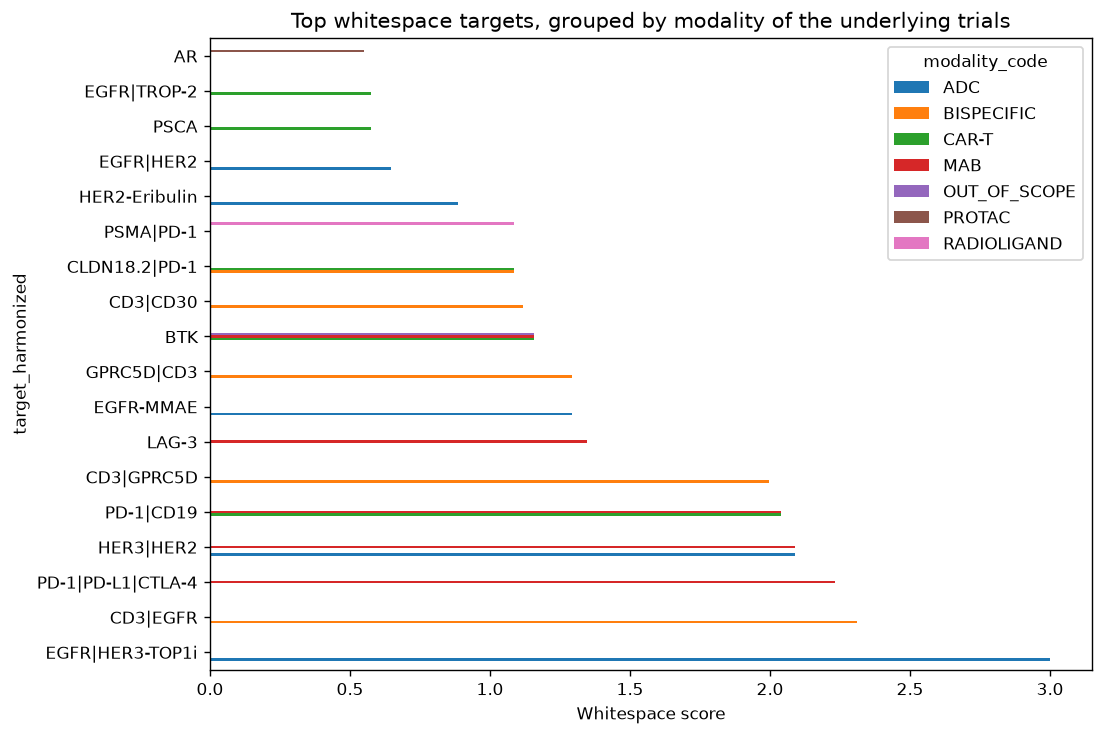

In [23]:
top_ws = WHITESPACE_OVERALL.head(40)
mod_map = df[df["target_h"].isin(top_ws["target_harmonized"])].groupby(["target_h", "modality_code"]).size().reset_index(name="n_trials")
merged = mod_map.merge(top_ws[["target_harmonized", "whitespace_score"]], left_on="target_h", right_on="target_harmonized")
by_modality = (merged.sort_values(["modality_code", "whitespace_score"], ascending=[True, False])
                      .groupby("modality_code").head(5)[["modality_code", "target_h", "n_trials", "whitespace_score"]]
                      .rename(columns={"target_h": "target_harmonized"}))
display(by_modality, name="entry23_whitespace_by_modality")

fig, ax = plt.subplots(figsize=(9, 6))
piv = by_modality.pivot_table(index="target_harmonized", columns="modality_code", values="whitespace_score", fill_value=0)
piv = piv.loc[by_modality.sort_values("whitespace_score", ascending=False)["target_harmonized"].unique()]
piv.plot(kind="barh", ax=ax, color=plt.cm.tab10.colors[:piv.shape[1]])
ax.set_xlabel("Whitespace score"); ax.set_title("Top whitespace targets, grouped by modality of the underlying trials")
plt.tight_layout()

## Entry 24: Whitespace Targets by Solid Tumor Type

,tumor_type,target_harmonized,n_trials,whitespace_score
0,Adrenal,B7-H3|WT1,1,-0.255659
18,Biliary_Cholangio,IL1RAP,1,1.077334
10,Biliary_Cholangio,CTLA-4|HER2|PD-1|PD-L1,2,0.916525
9,Biliary_Cholangio,CLDN18.2|CTLA-4|PD-1|PD-L1,1,0.770888
28,Biliary_Cholangio,PD-L1|FGFR,2,0.410036
30,Biliary_Cholangio,TROP-2|VEGF,1,0.410036
34,Bladder_Urothelial,BTK,1,1.155729
47,Bladder_Urothelial,IL1RAP,1,1.077334
40,Bladder_Urothelial,CTLA-4|HER2|PD-1|PD-L1,1,0.916525
35,Bladder_Urothelial,CCR8,1,0.574230


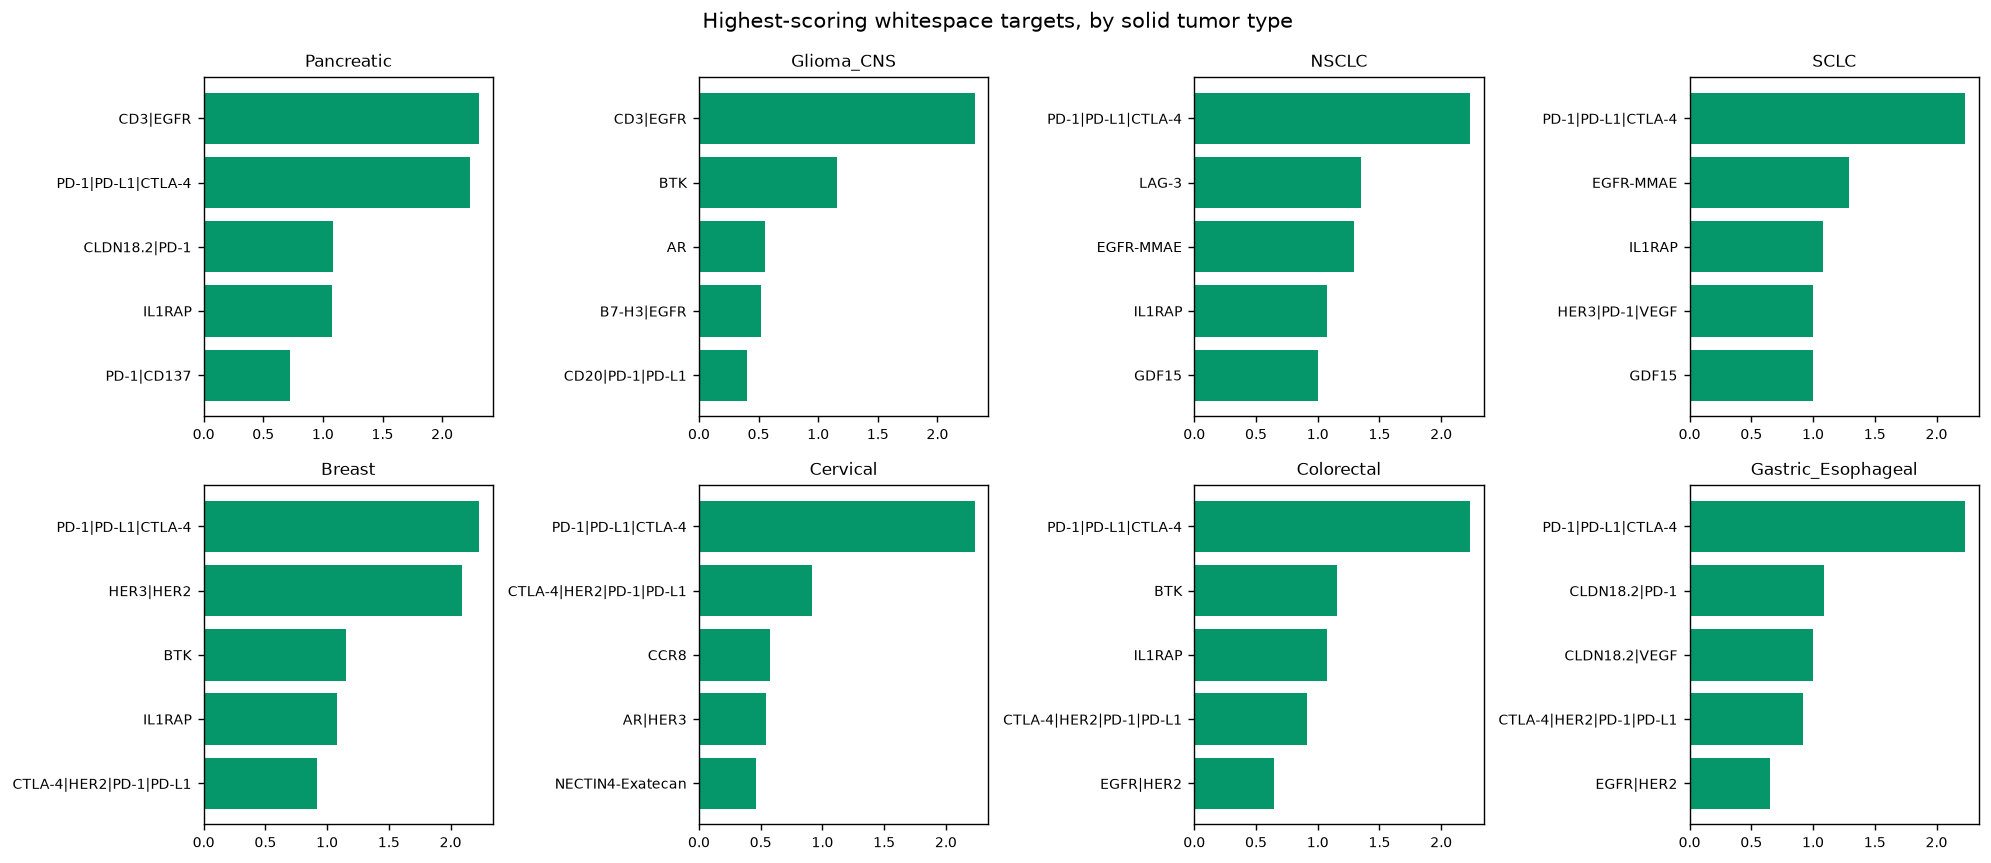

In [24]:
ws_targets = WHITESPACE_OVERALL["target_harmonized"].tolist()
ws_junction = tumor_junction[
    tumor_junction["target_h"].isin(ws_targets) &
    ~tumor_junction["tumor_type"].str.startswith("Hematologic") &
    (tumor_junction["tumor_type"] != "Solid_Tumor_Basket")
]
q = ws_junction.groupby(["tumor_type", "target_h"]).size().reset_index(name="n_trials")
q = q.merge(WHITESPACE_OVERALL[["target_harmonized", "whitespace_score"]], left_on="target_h", right_on="target_harmonized")
q = q.sort_values(["tumor_type", "whitespace_score"], ascending=[True, False]).groupby("tumor_type").head(5)
q = q[["tumor_type", "target_h", "n_trials", "whitespace_score"]].rename(columns={"target_h": "target_harmonized"})
display(q, name="entry24_whitespace_by_tumor_type")

top_tumors = (q.groupby("tumor_type")["whitespace_score"].max().sort_values(ascending=False).head(8).index.tolist())
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, tt in zip(axes.flat, top_tumors):
    sub = q[q["tumor_type"] == tt].sort_values("whitespace_score")
    ax.barh(sub["target_harmonized"], sub["whitespace_score"], color="#059669")
    ax.set_title(tt, fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle("Highest-scoring whitespace targets, by solid tumor type")
plt.tight_layout()

## Entry 25: Portfolio Recommendation Shortlist -- Candidate Target/Modality/Tumor-Type Bets

In [25]:
ws_junction = tumor_junction[
    tumor_junction["target_h"].isin(WHITESPACE_OVERALL["target_harmonized"]) &
    ~tumor_junction["tumor_type"].str.startswith("Hematologic") &
    (tumor_junction["tumor_type"] != "Solid_Tumor_Basket")
]
tt_counts = ws_junction.groupby(["target_h", "tumor_type"]).size().reset_index(name="n_trials_in_tumor")
best_tumor = tt_counts.sort_values("n_trials_in_tumor", ascending=False).drop_duplicates("target_h")

mod_counts = df[df["target_h"].isin(WHITESPACE_OVERALL["target_harmonized"])].groupby(["target_h", "modality_code"]).size().reset_index(name="n_trials_in_modality")
best_modality = mod_counts.sort_values("n_trials_in_modality", ascending=False).drop_duplicates("target_h")

shortlist = WHITESPACE_OVERALL.head(15).copy()
shortlist = shortlist.merge(best_tumor.rename(columns={"target_h": "target_harmonized"}), on="target_harmonized", how="left")
shortlist = shortlist.merge(best_modality.rename(columns={"target_h": "target_harmonized"}), on="target_harmonized", how="left")

def rationale(row):
    bits = [f"{row['n_trials']} trials since {int(row['earliest_start_year'])}", f"{row['n_sponsors']} sponsor(s) (low crowding)"]
    if row["n_success"] > 0:
        bits.append(f"{int(row['n_success'])} early positive readout(s)")
    else:
        bits.append("no failures recorded yet")
    if pd.notna(row.get("tumor_type")):
        bits.append(f"concentrated in {row['tumor_type']}")
    if pd.notna(row.get("modality_code")):
        bits.append(f"lead modality tested: {row['modality_code']}")
    return "; ".join(bits)

shortlist["rationale"] = shortlist.apply(rationale, axis=1)
cols = ["target_harmonized", "n_trials", "n_sponsors", "tumor_type", "modality_code", "whitespace_score", "rationale"]
display(shortlist[cols], name="entry25_portfolio_shortlist")

,target_harmonized,n_trials,n_sponsors,tumor_type,modality_code,whitespace_score,rationale
0,EGFR|HER3-TOP1i,6,1,-,ADC,2.998851,6 trials since 2026; 1 sponsor(s) (low crowding); 2 early positive readout(s); lead modality tested: ADC
1,CD3|EGFR,5,3,Pancreatic,BISPECIFIC,2.311632,5 trials since 2015; 3 sponsor(s) (low crowding); 2 early positive readout(s); concentrated in Pancreatic; lead modality tested: BISPECIFIC
2,PD-1|PD-L1|CTLA-4,4,4,Lung_Other,MAB,2.232466,4 trials since 2021; 4 sponsor(s) (low crowding); 2 early positive readout(s); concentrated in Lung_Other; lead modality tested: MAB
3,HER3|HER2,5,5,Breast,MAB,2.089859,5 trials since 2014; 5 sponsor(s) (low crowding); 2 early positive readout(s); concentrated in Breast; lead modality tested: MAB
4,PD-1|CD19,6,6,Ovarian,MAB,2.040756,6 trials since 2019; 6 sponsor(s) (low crowding); 2 early positive readout(s); concentrated in Ovarian; lead modality tested: MAB
5,CD3|GPRC5D,3,3,-,BISPECIFIC,1.997442,3 trials since 2017; 3 sponsor(s) (low crowding); 2 early positive readout(s); lead modality tested: BISPECIFIC
6,LAG-3,5,4,Lung_Other,MAB,1.347197,5 trials since 2020; 4 sponsor(s) (low crowding); 1 early positive readout(s); concentrated in Lung_Other; lead modality tested: MAB
7,GPRC5D|CD3,5,5,-,BISPECIFIC,1.293977,5 trials since 2021; 5 sponsor(s) (low crowding); 1 early positive readout(s); lead modality tested: BISPECIFIC
8,EGFR-MMAE,5,5,NSCLC,ADC,1.293977,5 trials since 2020; 5 sponsor(s) (low crowding); 1 early positive readout(s); concentrated in NSCLC; lead modality tested: ADC
9,BTK,8,7,Glioma_CNS,MAB,1.155729,8 trials since 2011; 7 sponsor(s) (low crowding); 1 early positive readout(s); concentrated in Glioma_CNS; lead modality tested: MAB


## Entry 26: Executive Summary & Key Findings

In [26]:
top_modality = con.sql("SELECT modality_code, COUNT(*) n FROM trials GROUP BY 1 ORDER BY 2 DESC LIMIT 1").df().iloc[0]
top_target_row = TARGET_SCORECARD.sort_values("n_trials", ascending=False).iloc[0]
n_validated = (TARGET_SCORECARD["target_status"] == "Validated (success recorded)").sum()
n_mixed = (TARGET_SCORECARD["target_status"] == "Mixed (succeeded & failed)").sum()
n_failed_only = (TARGET_SCORECARD["target_status"] == "Failed only (no success yet)").sum()
n_still_trial = (TARGET_SCORECARD["target_status"] == "Still-in-trial (no readout yet)").sum()
n_regimen_flagged = (REGIMEN_DIVERGENCE["divergence_flag"] != "No clear divergence").sum()
n_modality_flagged = (MODALITY_DIVERGENCE["divergence_flag"] != "No clear divergence").sum()
n_whitespace = len(WHITESPACE_OVERALL)
top_ws_target = WHITESPACE_OVERALL.iloc[0]["target_harmonized"]

print("EXECUTIVE SUMMARY -- Antibody Oncology Clinical Landscape")
print("=" * 70)
print(f"Universe analyzed: {len(df):,} in-scope antibody-modality oncology trial records "
      f"({df['nct'].nunique():,} unique NCT numbers).")
print(f"Dominant modality: {top_modality['modality_code']} ({int(top_modality['n']):,} trials).")
print(f"Most clinically active target: {top_target_row['target_harmonized']} "
      f"({int(top_target_row['n_trials'])} trials, {top_target_row['success_rate_%']:.1f}% success rate).")
print()
print(f"Among {len(TARGET_SCORECARD)} targets with >=5 trials:")
print(f"  - {n_validated} are VALIDATED (>=1 recorded clinical success/approval)")
print(f"  - {n_mixed} are MIXED (succeeded in some settings, failed in others)")
print(f"  - {n_failed_only} have FAILED ONLY so far (no success recorded)")
print(f"  - {n_still_trial} are STILL IN TRIAL with no readout yet")
print()
print(f"{n_regimen_flagged} targets show a clear IO-combo vs monotherapy outcome divergence.")
print(f"{n_modality_flagged} targets show a clear naked-mAb vs ADC outcome divergence.")
print()
print(f"{n_whitespace} targets qualify as clinical WHITESPACE (Phase 1/2 only, zero failures, active since 2019).")
print(f"Top-ranked whitespace target: {top_ws_target}.")

EXECUTIVE SUMMARY -- Antibody Oncology Clinical Landscape
Universe analyzed: 16,648 in-scope antibody-modality oncology trial records (15,851 unique NCT numbers).
Dominant modality: MAB (12,446 trials).
Most clinically active target: PD-1 (2908 trials, 12.0% success rate).

Among 243 targets with >=5 trials:
  - 21 are VALIDATED (>=1 recorded clinical success/approval)
  - 99 are MIXED (succeeded in some settings, failed in others)
  - 83 have FAILED ONLY so far (no success recorded)
  - 40 are STILL IN TRIAL with no readout yet

1 targets show a clear IO-combo vs monotherapy outcome divergence.
14 targets show a clear naked-mAb vs ADC outcome divergence.

711 targets qualify as clinical WHITESPACE (Phase 1/2 only, zero failures, active since 2019).
Top-ranked whitespace target: EGFR|HER3-TOP1i.
